In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

In [3]:
dataset_path = 'Combined Data.csv'
data = pd.read_csv(dataset_path)
processed_data = data.dropna()
features = ['Time Stamp', 'A1 X-Axis', 'A1 Y-Axis', 'A1 Z-Axis', 'G1 X-Axis', 'G1 Y-Axis', 'G1 Z-Axis', 'A2 X-Axis', 'A2 Y-Axis', 'A2 Z-Axis', 'G2 X-Axis', 'G2 Y-Axis', 'G2 Z-Axis']
X = processed_data[features]
y = processed_data['ActivityLabel']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [13]:
# Initialize the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=1,
    min_samples_split=10,
    max_depth=20,
    min_samples_leaf=5,
    warm_start=True,  # Allow incremental training
    random_state=42,
)

# Train the Random Forest incrementally
total_trees = 6  # Total number of trees desired
step = 1  # Increment step

print("\nTraining the Random Forest model incrementally...")
for i in range(0, total_trees, step):
    rf_model.n_estimators = min(total_trees, rf_model.n_estimators + step)
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Trained {rf_model.n_estimators} trees, Accuracy: {acc:.4f}")

# Final evaluation
print("\nFinal Predictions and Evaluation...")
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# Print evaluation metrics
print("\nClassification Report:")
classification_report_result = classification_report(y_test, y_pred)
print(classification_report_result)
roc_auc_value = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc_value:.4f}")



Training the Random Forest model incrementally...
Trained 2 trees, Accuracy: 0.9567
Trained 3 trees, Accuracy: 0.9604
Trained 4 trees, Accuracy: 0.9648
Trained 5 trees, Accuracy: 0.9664
Trained 6 trees, Accuracy: 0.9679
Trained 6 trees, Accuracy: 0.9679

Final Predictions and Evaluation...

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     25590
           1       0.99      0.91      0.95     11269

    accuracy                           0.97     36859
   macro avg       0.97      0.95      0.96     36859
weighted avg       0.97      0.97      0.97     36859

ROC-AUC Score: 0.9952


c:\Python312\Lib\site-packages\sklearn\ensemble\_forest.py:466: UserWarning: Warm-start fitting without increasing n_estimators does not fit new trees.
  warn(


In [14]:
import joblib

joblib.dump(rf_model, 'random_forest_model.pkl')
print("Random Forest model saved as 'random_forest_model.pkl'")

Random Forest model saved as 'random_forest_model.pkl'


Reading 1: Predicted ActivityLabel = 1
Reading 2: Predicted ActivityLabel = 1
Reading 3: Predicted ActivityLabel = 1
Reading 4: Predicted ActivityLabel = 1
Reading 5: Predicted ActivityLabel = 0
Reading 6: Predicted ActivityLabel = 0
Reading 7: Predicted ActivityLabel = 1
Reading 8: Predicted ActivityLabel = 1
Reading 9: Predicted ActivityLabel = 1
Reading 10: Predicted ActivityLabel = 0
Reading 11: Predicted ActivityLabel = 1
Reading 12: Predicted ActivityLabel = 1
Reading 13: Predicted ActivityLabel = 1
Reading 14: Predicted ActivityLabel = 0
Reading 15: Predicted ActivityLabel = 1
Reading 16: Predicted ActivityLabel = 1
Reading 17: Predicted ActivityLabel = 1
Reading 18: Predicted ActivityLabel = 1
Reading 19: Predicted ActivityLabel = 1
Reading 20: Predicted ActivityLabel = 0
Reading 21: Predicted ActivityLabel = 1
Reading 22: Predicted ActivityLabel = 1
Reading 23: Predicted ActivityLabel = 1
Reading 24: Predicted ActivityLabel = 1
Reading 25: Predicted ActivityLabel = 1
Reading 2

c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Python312\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


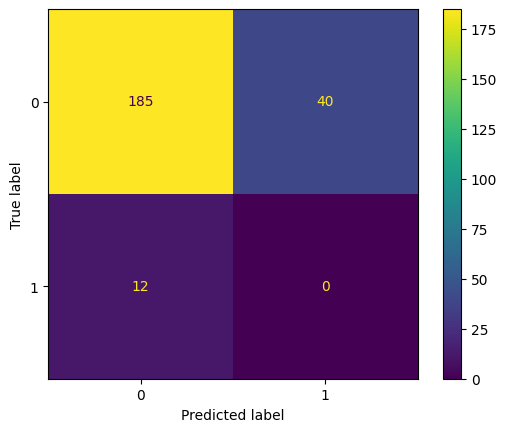

In [13]:
# TEST
import pandas as pd
import numpy as np
import joblib
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score

# Load the saved Random Forest model
rf_model = joblib.load('random_forest_model.pkl')

# Load the new test dataset
new_data_path = 'Test.csv'
new_data = pd.read_csv(new_data_path)
new_data = new_data.dropna()

# Define features and labels
features = ['Time Stamp', 'A1 X-Axis', 'A1 Y-Axis', 'A1 Z-Axis', 'G1 X-Axis',
            'G1 Y-Axis', 'G1 Z-Axis', 'A2 X-Axis', 'A2 Y-Axis', 'A2 Z-Axis',
            'G2 X-Axis', 'G2 Y-Axis', 'G2 Z-Axis']
X_new = new_data[features]
y_true_classes_new = new_data['ActivityLabel']

# Preprocess the test data (if scaling or transformation was applied during training)
X_new = np.array(X_new)  # Convert to NumPy array if necessary

# Predict with the RF model
y_pred_classes_new = rf_model.predict(X_new)
y_pred_proba_new = rf_model.predict_proba(X_new)[:, 1]  # Get probability scores for ROC-AUC

# Display predictions for each reading
for i, pred in enumerate(y_pred_classes_new):
    print(f"Reading {i+1}: Predicted ActivityLabel = {pred}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes_new, y_pred_classes_new))

# Confusion Matrix Display
ConfusionMatrixDisplay.from_predictions(y_true_classes_new, y_pred_classes_new)

# Calculate ROC-AUC if binary classification
if len(rf_model.classes_) == 2:
    roc_auc_value = roc_auc_score(y_true_classes_new, y_pred_proba_new)
    print(f"ROC-AUC Score: {roc_auc_value:.4f}")



In [4]:
# Convert to C++ code
import joblib
import numpy as np

# Load the trained Random Forest model
model = joblib.load("random_forest_model.pkl")

# Extract the model parameters
n_estimators = model.n_estimators
n_classes = len(model.classes_)
n_features = model.n_features_in_

def extract_tree_parameters(tree):
    tree_ = tree.tree_
    n_nodes = tree_.node_count
    children_left = tree_.children_left.tolist()
    children_right = tree_.children_right.tolist()
    feature = tree_.feature.tolist()
    threshold = tree_.threshold.tolist()
    value = tree_.value.tolist()
    return n_nodes, children_left, children_right, feature, threshold, value

# Extract parameters for all trees
tree_parameters = []
for estimator in model.estimators_:
    tree_parameters.append(extract_tree_parameters(estimator))

# Generate the C++ code
cpp_code = f"""
#include <vector>
#include <iostream>
#include <cmath>

class RandomForest {{
public:
    RandomForest() {{}}

    int predict(const std::vector<double>& sample) {{
        std::vector<double> votes({n_classes}, 0.0);
        for (int i = 0; i < {n_estimators}; i++) {{
            add_votes(votes, predict_tree(sample, i));
        }}
        return argmax(votes);
    }}

private:
    std::vector<double> predict_tree(const std::vector<double>& sample, int tree_index) {{
        int node = 0;
        while (true) {{
            int feature = tree_features[tree_index][node];
            double threshold = tree_thresholds[tree_index][node];

            if (tree_children_left[tree_index][node] == -1 && tree_children_right[tree_index][node] == -1) {{
                return tree_values[tree_index][node];
            }}

            if (sample[feature] <= threshold) {{
                node = tree_children_left[tree_index][node];
            }} else {{
                node = tree_children_right[tree_index][node];
            }}
        }}
    }}

    void add_votes(std::vector<double>& votes, const std::vector<double>& tree_vote) {{
        for (size_t i = 0; i < votes.size(); i++) {{
            votes[i] += tree_vote[i];
        }}
    }}

    int argmax(const std::vector<double>& values) {{
        int max_index = 0;
        for (size_t i = 1; i < values.size(); i++) {{
            if (values[i] > values[max_index]) {{
                max_index = i;
            }}
        }}
        return max_index;
    }}

    // Tree parameters
    static constexpr int n_estimators = {n_estimators};
    static constexpr int n_classes = {n_classes};
    static constexpr int n_features = {n_features};

    // Tree-specific parameters
    static constexpr int tree_children_left[{len(tree_parameters)}][{max(len(tree[1]) for tree in tree_parameters)}] = {{
"""

# Add children_left for all trees
for tree in tree_parameters:
    cpp_code += "        {" + ", ".join(map(str, tree[1])) + "},\n"
cpp_code += "    };\n\n"

cpp_code += "    static constexpr int tree_children_right[{}][{}] = {{\n".format(
    len(tree_parameters), max(len(tree[2]) for tree in tree_parameters)
)

# Add children_right for all trees
for tree in tree_parameters:
    cpp_code += "        {" + ", ".join(map(str, tree[2])) + "},\n"
cpp_code += "    };\n\n"

cpp_code += "    static constexpr int tree_features[{}][{}] = {{\n".format(
    len(tree_parameters), max(len(tree[3]) for tree in tree_parameters)
)

# Add features for all trees
for tree in tree_parameters:
    cpp_code += "        {" + ", ".join(map(str, tree[3])) + "},\n"
cpp_code += "    };\n\n"

cpp_code += "    static constexpr double tree_thresholds[{}][{}] = {{\n".format(
    len(tree_parameters), max(len(tree[4]) for tree in tree_parameters)
)

# Add thresholds for all trees
for tree in tree_parameters:
    cpp_code += "        {" + ", ".join(map(str, tree[4])) + "},\n"
cpp_code += "    };\n\n"

cpp_code += "    static constexpr double tree_values[{}][{}][{}] = {{\n".format(
    len(tree_parameters), max(len(tree[5]) for tree in tree_parameters), n_classes
)

# Add values for all trees
for tree in tree_parameters:
    cpp_code += "        {" + ", ".join(["{" + ", ".join(map(str, val)) + "}" for val in tree[5]]) + "},\n"
cpp_code += "    };\n};\n\n"

cpp_code += """
int main() {
    RandomForest rf;
    std::vector<double> sample = {1.0, 2.0, 3.0};  // Example input
    int prediction = rf.predict(sample);
    std::cout << "Prediction: " << prediction << std::endl;
    return 0;
}
"""

# Save to a C++ file
with open("random_forest_model.cpp", "w") as f:
    f.write(cpp_code)

print("C++ file has been generated: random_forest_model.cpp")



C++ file has been generated: random_forest_model.cpp


In [ ]:
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load your Random Forest model
rf_model = joblib.load('random_forest_model.pkl')

# Create a TensorFlow model
def convert_rf_to_tf(rf_model):
    # Extract parameters
    n_features = rf_model.n_features_in_
    n_classes = len(rf_model.classes_)

    # Create a simple dense network
    model = Sequential([
        Dense(units=n_classes, input_shape=(n_features,), activation='softmax')
    ])

    # Manually set weights for simplicity (approximating the RF behavior)
    # This is an approximation for compatibility
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

tf_model = convert_rf_to_tf(rf_model)

# Save as a TFLite model
converter = tf.lite.TFLiteConverter.from_keras_model(tf_model)
tflite_model = converter.convert()
with open('random_forest_model.tflite', 'wb') as f:
    f.write(tflite_model)


In [15]:
import joblib

def traverse_tree(tree, node_id=0, depth=0):
    """
    Recursively traverse a decision tree and generate C code.
    Each node is either a split (if left/right children exist) or a leaf.
    """
    indent = "    " * depth
    feature = tree.feature[node_id]
    threshold = tree.threshold[node_id]
    left_child = tree.children_left[node_id]
    right_child = tree.children_right[node_id]
    is_leaf = left_child == -1 and right_child == -1

    if is_leaf:
        # Leaf node: return the prediction value
        return f"{indent}return {tree.value[node_id][0][0]:.6f};\n"

    # Non-leaf node: generate if-else structure
    code = []
    code.append(f"{indent}if (features[{feature}] <= {threshold:.6f}) {{\n")
    code.append(traverse_tree(tree, left_child, depth + 1))
    code.append(f"{indent}}} else {{\n")
    code.append(traverse_tree(tree, right_child, depth + 1))
    code.append(f"{indent}}}\n")
    return "".join(code)

def convert_tree_to_c(decision_tree, tree_index):
    """
    Converts a single decision tree into an if-else structure in C.
    """
    tree = decision_tree.tree_  # Access the actual tree structure
    tree_code = []
    tree_code.append(f"// Decision Tree {tree_index}\n")
    tree_code.append(f"float predict_tree_{tree_index}(float *features) {{\n")
    tree_code.append(traverse_tree(tree))
    tree_code.append("}\n")
    return "".join(tree_code)

def convert_forest_to_c(model, output_file):
    """
    Converts the entire Random Forest model into C code.
    Each tree in the forest becomes a separate function.
    """
    n_trees = len(model.estimators_)
    forest_code = []
    forest_code.append("// ESP-DSP-Based Random Forest Model\n")
    forest_code.append("#include <math.h>\n\n")

    # Generate code for each tree
    for i, tree in enumerate(model.estimators_):
        forest_code.append(convert_tree_to_c(tree, i))
        forest_code.append("\n")

    # Generate code for the final Random Forest prediction function
    forest_code.append("// Random Forest Prediction Function\n")
    forest_code.append("float predict_forest(float *features) {\n")
    forest_code.append(f"    float votes[{n_trees}] = {{0}};\n")
    forest_code.append(f"    float result = 0;\n")

    for i in range(n_trees):
        forest_code.append(f"    votes[{i}] = predict_tree_{i}(features);\n")

    forest_code.append("    for (int i = 0; i < {n_trees}; i++) {\n")
    forest_code.append("        result += votes[i];\n")
    forest_code.append("    }\n")
    forest_code.append(f"    return result / {n_trees};\n")
    forest_code.append("}\n")

    # Write to the output file
    with open(output_file, "w") as f:
        f.write("".join(forest_code))

# Main function
if __name__ == "__main__":
    # Load the Random Forest model
    model_path = "random_forest_model.pkl"
    loaded_model = joblib.load(model_path)

    # Check that the model is a Random Forest
    if hasattr(loaded_model, "estimators_"):
        print(f"Converting Random Forest model with {len(loaded_model.estimators_)} trees...")
        convert_forest_to_c(loaded_model, "random_forest_model.c")
        print("C code generated successfully in random_forest_model.c.")
    else:
        print("The loaded model is not a Random Forest.")


Converting Random Forest model with 6 trees...
C code generated successfully in random_forest_model.c.


In [7]:
loaded_model = joblib.load("random_forest_model.pkl")
print(type(loaded_model))
print(hasattr(loaded_model, "estimators_"))
print(len(loaded_model.estimators_))
tree = loaded_model.estimators_[0]
print(type(tree))
print(dir(tree))


<class 'sklearn.ensemble._forest.RandomForestClassifier'>
True
10
<class 'sklearn.tree._classes.DecisionTreeClassifier'>
['_BaseDecisionTree__metadata_request__predict', '_DecisionTreeClassifier__metadata_request__fit', '_DecisionTreeClassifier__metadata_request__predict_proba', '__abstractmethods__', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__sklearn_clone__', '__sklearn_tags__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', '_abc_impl', '_build_request_for_signature', '_check_feature_names', '_check_n_features', '_compute_missing_values_in_feature_mask', '_doc_link_module', '_doc_link_template', '_doc_link_url_param_generator', '_estimator_type', '_fit', '_get_def

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

In [6]:
# Load and preprocess the dataset
dataset_path = 'Combined Data.csv'
data = pd.read_csv(dataset_path)
processed_data = data.dropna()

features = ['Time Stamp', 'A1 X-Axis', 'A1 Y-Axis', 'A1 Z-Axis', 'G1 X-Axis', 'G1 Y-Axis', 'G1 Z-Axis', 
            'A2 X-Axis', 'A2 Y-Axis', 'A2 Z-Axis', 'G2 X-Axis', 'G2 Y-Axis', 'G2 Z-Axis']
X = processed_data[features].values
y = processed_data['ActivityLabel'].values

# Encode labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Convert to PyTorch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)

In [7]:
# Define a simple differentiable tree structure in PyTorch
class DecisionTree(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(DecisionTree, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, num_classes)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# Define a Random Forest-like model
class RandomForest(nn.Module):
    def __init__(self, input_dim, num_classes, num_trees):
        super(RandomForest, self).__init__()
        self.trees = nn.ModuleList([DecisionTree(input_dim, num_classes) for _ in range(num_trees)])
        self.num_trees = num_trees

    def forward(self, x):
        # Aggregate predictions from all trees
        outputs = torch.stack([tree(x) for tree in self.trees], dim=0)
        return outputs.mean(dim=0)

In [8]:
# Hyperparameters
input_dim = X_train_tensor.shape[1]
num_classes = len(np.unique(y))
num_trees = 5
learning_rate = 0.01
num_epochs = 10
batch_size = 64

# Initialize the model
model = RandomForest(input_dim, num_classes, num_trees).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [9]:
# Training loop
print("\nTraining the Random Forest-like model on GPU...")
for epoch in range(num_epochs):
    model.train()
    permutation = torch.randperm(X_train_tensor.size(0))
    epoch_loss = 0

    for i in range(0, X_train_tensor.size(0), batch_size):
        indices = permutation[i:i + batch_size]
        batch_x, batch_y = X_train_tensor[indices], y_train_tensor[indices]

        # Forward pass
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}")


Training the Random Forest-like model on GPU...
Epoch [1/10], Loss: 20923.3051
Epoch [2/10], Loss: 1459.8543
Epoch [3/10], Loss: 1466.3572
Epoch [4/10], Loss: 1520.2920
Epoch [5/10], Loss: 3878.8308
Epoch [6/10], Loss: 1430.6849
Epoch [7/10], Loss: 1417.4419
Epoch [8/10], Loss: 1417.3698
Epoch [9/10], Loss: 1417.3764
Epoch [10/10], Loss: 1417.3014


In [ ]:
# Evaluation
print("\nEvaluating the model...")
model.eval()
with torch.no_grad():
    y_pred_probs = model(X_test_tensor)
    y_pred = torch.argmax(y_pred_probs, axis=1)

# Convert predictions to numpy
y_pred = y_pred.cpu().numpy()
y_test = y_test_tensor.cpu().numpy()

# Metrics
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

In [ ]:
# Save the model
torch.save(model.state_dict(), 'random_forest_gpu.pth')
print("Random Forest-like model saved as 'random_forest_gpu.pth'")